In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
titanic = fetch_openml('titanic', version=1, as_frame=True)
df = titanic.data

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (1309, 13)
   pclass                                             name     sex      age  \
0       1                    Allen, Miss. Elisabeth Walton  female  29.0000   
1       1                   Allison, Master. Hudson Trevor    male   0.9167   
2       1                     Allison, Miss. Helen Loraine  female   2.0000   
3       1             Allison, Mr. Hudson Joshua Creighton    male  30.0000   
4       1  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female  25.0000   

   sibsp  parch  ticket      fare    cabin embarked boat   body  \
0      0      0   24160  211.3375       B5        S    2    NaN   
1      1      2  113781  151.5500  C22 C26        S   11    NaN   
2      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  
0                     St Louis, MO  
1  Montreal, PQ / Ches

In [12]:
features = ['age', 'fare', 'sibsp', 'parch', 'pclass']
X = df[features].copy()

In [18]:
features = ['age', 'fare', 'sibsp', 'parch', 'pclass']
X = df[features].copy()

In [19]:
kmeans_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=3, random_state=42, n_init=10))
])

In [22]:
kmeans_pipeline.fit(X)
kmeans_labels = kmeans_pipeline.predict(X)
X_transformed = kmeans_pipeline.named_steps['scaler'].transform(kmeans_pipeline.named_steps['imputer'].transform(X))
kmeans_score = silhouette_score(X_transformed, kmeans_labels)

print("\nK-Means Clustering:")
print("Silhouette Score:", kmeans_score)
print("Cluster counts:", np.bincount(kmeans_labels))


K-Means Clustering:
Silhouette Score: 0.4194958920057144
Cluster counts: [354 805 150]


In [25]:
hierarchical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('hierarchical', AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward'))
])

hierarchical_pipeline.fit(X)
hierarchical_labels = hierarchical_pipeline.named_steps['hierarchical'].labels_
X_transformed_hierarchical = hierarchical_pipeline.named_steps['scaler'].transform(hierarchical_pipeline.named_steps['imputer'].transform(X))
hierarchical_score = silhouette_score(X_transformed_hierarchical, hierarchical_labels)

print("\nHierarchical Clustering:")
print("Silhouette Score:", hierarchical_score)
print("Cluster counts:", np.bincount(hierarchical_labels))


Hierarchical Clustering:
Silhouette Score: 0.39819220792287713
Cluster counts: [334 204 771]


In [27]:
dbscan_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('dbscan', DBSCAN(eps=0.5, min_samples=5))
])

dbscan_pipeline.fit(X)
X_transformed_dbscan = dbscan_pipeline.named_steps['scaler'].transform(dbscan_pipeline.named_steps['imputer'].transform(X))
dbscan_labels = dbscan_pipeline.named_steps['dbscan'].labels_
# DBSCAN may have -1 as noise, so we count only valid clusters
unique_labels = set(dbscan_labels)
noise_count = dbscan_labels[dbscan_labels == -1].shape[0]
valid_labels = [l for l in unique_labels if l != -1]

if len(valid_labels) > 1:  # Only compute silhouette if more than 1 cluster
    # Ensure silhouette_score is computed on the transformed data
    dbscan_score = silhouette_score(X_transformed_dbscan, dbscan_labels)
else:
    dbscan_score = -1  # Not applicable

print("\nDBSCAN Clustering:")
print("Silhouette Score:", dbscan_score if dbscan_score != -1 else "Not applicable (too few clusters)")
print("Total samples:", len(X))
print("Noise points:", noise_count)
print("Valid clusters:", len(valid_labels))
print("Cluster counts:", {label: np.sum(dbscan_labels == label) for label in valid_labels})


DBSCAN Clustering:
Silhouette Score: 0.25160270057297524
Total samples: 1309
Noise points: 194
Valid clusters: 28
Cluster counts: {np.int64(0): np.int64(8), np.int64(1): np.int64(126), np.int64(2): np.int64(67), np.int64(3): np.int64(7), np.int64(4): np.int64(10), np.int64(5): np.int64(8), np.int64(6): np.int64(4), np.int64(7): np.int64(5), np.int64(8): np.int64(39), np.int64(9): np.int64(153), np.int64(10): np.int64(16), np.int64(11): np.int64(5), np.int64(12): np.int64(10), np.int64(13): np.int64(463), np.int64(14): np.int64(40), np.int64(15): np.int64(64), np.int64(16): np.int64(7), np.int64(17): np.int64(10), np.int64(18): np.int64(8), np.int64(19): np.int64(8), np.int64(20): np.int64(5), np.int64(21): np.int64(14), np.int64(22): np.int64(6), np.int64(23): np.int64(5), np.int64(24): np.int64(5), np.int64(25): np.int64(5), np.int64(26): np.int64(9), np.int64(27): np.int64(8)}


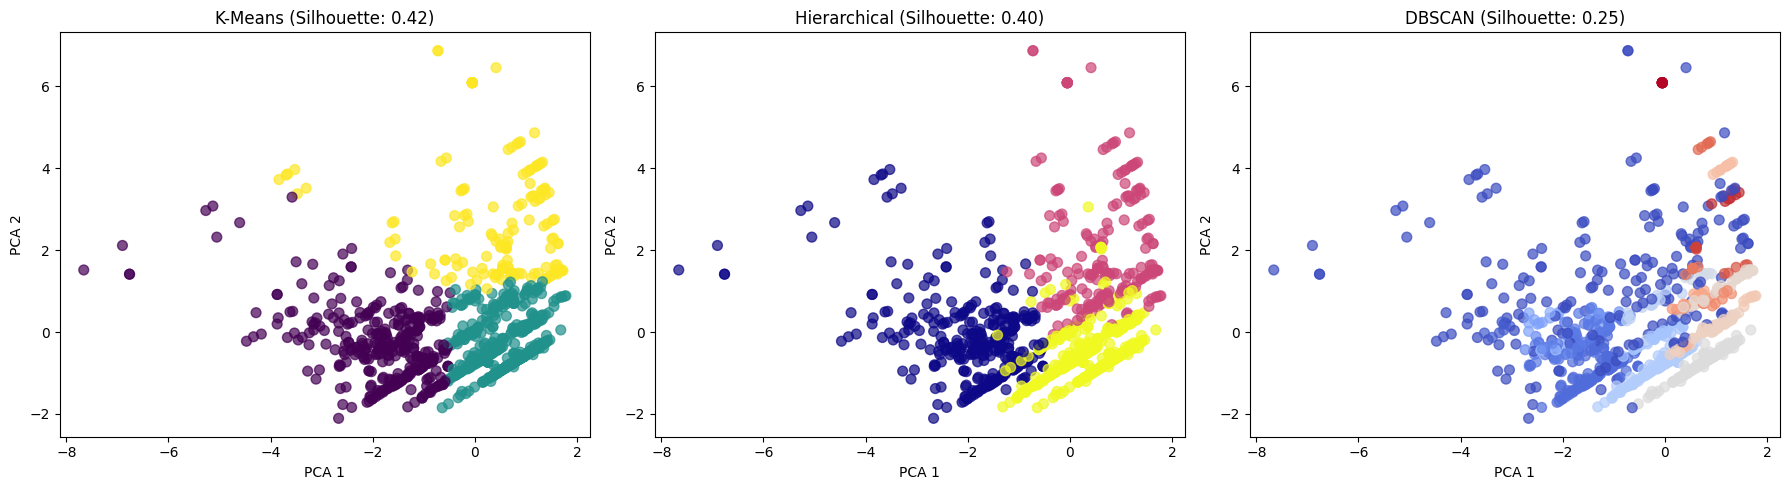

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_transformed)

# Plot all three methods
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=50, alpha=0.7)
axes[0].set_title('K-Means (Silhouette: {:.2f})'.format(kmeans_score))
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')

# Hierarchical
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels, cmap='plasma', s=50, alpha=0.7)
axes[1].set_title('Hierarchical (Silhouette: {:.2f})'.format(hierarchical_score))
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')

# DBSCAN
axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='coolwarm', s=50, alpha=0.7)
axes[2].set_title('DBSCAN (Silhouette: {:.2f})'.format(dbscan_score if dbscan_score != -1 else 'N/A'))
axes[2].set_xlabel('PCA 1')
axes[2].set_ylabel('PCA 2')

plt.tight_layout()
plt.show()